# Loading and Visualizing Synthetic Seismic Dataset

This notebook demonstrates how to load and explore the synthetic seismogram dataset created with SeisBench format.

## 1. Import Required Libraries

In [1]:
import seisbench.data as sbd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Load Dataset from Disk

Load the synthetic dataset using SeisBench's `WaveformDataset` class by pointing to the directory containing `metadata.csv` and `waveforms.hdf5`.

In [2]:
# Load the synthetic dataset
dataset = sbd.WaveformDataset('../data', sampling_rate=100)

print(f"Dataset loaded successfully!")
print(f"Number of traces: {len(dataset)}")
print(f"Sampling rate: {dataset.sampling_rate} Hz")

2026-02-10 17:07:50,982 | seisbench | WARNING | Component order not specified, defaulting to 'ZNE'.


Dataset loaded successfully!
Number of traces: 12
Sampling rate: 100 Hz


## 3. Inspect Metadata

The metadata is stored as a pandas DataFrame with information about each trace, including station info, phase picks, and source parameters.

In [3]:
# Display the first few rows of metadata
dataset.metadata.head()

,index,station_network_code,station_code,station_location_code,trace_channel,trace_sampling_rate_hz,trace_npts,trace_start_time,trace_p_arrival_sample,trace_p_status,...,source_origin_time,source_type,source_magnitude,source_magnitude_type,source_magnitude_author,trace_snr_db,split,trace_name,trace_chunk,trace_component_order
0,0,XX,SYN,NaN,HH,100.0,12000,1970-01-01T00:00:00,10795,manual,...,1970-01-01T00:00:00,earthquake,2.0,ML,synthetic,9.182615,train,"bucket0$0,:3,:12000",,ZNE
1,1,XX,SYN,NaN,HH,100.0,12000,1970-01-01T00:00:00,8299,manual,...,1970-01-01T00:00:00,earthquake,2.0,ML,synthetic,4.643954,train,"bucket0$1,:3,:12000",,ZNE
2,2,XX,SYN,NaN,HH,100.0,12000,1970-01-01T00:00:00,5997,manual,...,1970-01-01T00:00:00,earthquake,2.0,ML,synthetic,5.824702,train,"bucket0$2,:3,:12000",,ZNE
3,3,XX,SYN,NaN,HH,100.0,12000,1970-01-01T00:00:00,860,manual,...,1970-01-01T00:00:00,earthquake,2.0,ML,synthetic,8.411502,train,"bucket0$3,:3,:12000",,ZNE
4,4,XX,SYN,NaN,HH,100.0,12000,1970-01-01T00:00:00,10959,manual,...,1970-01-01T00:00:00,earthquake,2.0,ML,synthetic,7.321234,train,"bucket0$4,:3,:12000",,ZNE


In [4]:
# Show available columns
print("Available columns:")
for col in dataset.metadata.columns:
    print(f"  - {col}")

Available columns:
  - index
  - station_network_code
  - station_code
  - station_location_code
  - trace_channel
  - trace_sampling_rate_hz
  - trace_npts
  - trace_start_time
  - trace_p_arrival_sample
  - trace_p_status
  - trace_p_weight
  - trace_s_arrival_sample
  - trace_s_status
  - trace_s_weight
  - source_id
  - source_origin_time
  - source_type
  - source_magnitude
  - source_magnitude_type
  - source_magnitude_author
  - trace_snr_db
  - split
  - trace_name
  - trace_chunk
  - trace_component_order


In [5]:
# Display summary statistics
print("Dataset Summary:")
print(f"  Stations: {dataset.metadata['station_code'].nunique()}")
print(f"  Networks: {dataset.metadata['station_network_code'].nunique()}")
print(f"  Traces with P-picks: {dataset.metadata['trace_p_arrival_sample'].notna().sum()}")
print(f"  Traces with S-picks: {dataset.metadata['trace_s_arrival_sample'].notna().sum()}")
print(f"\nSNR Statistics:")
print(f"  Mean: {dataset.metadata['trace_snr_db'].mean():.2f} dB")
print(f"  Range: {dataset.metadata['trace_snr_db'].min():.2f} - {dataset.metadata['trace_snr_db'].max():.2f} dB")

Dataset Summary:
  Stations: 1
  Networks: 1
  Traces with P-picks: 12
  Traces with S-picks: 12

SNR Statistics:
  Mean: 6.67 dB
  Range: 4.29 - 9.78 dB


## 4. Load and Visualize a Single Trace

Get waveforms for a single trace and plot all three components (Z, N, E) with phase picks.

In [6]:
# Select trace index
trace_idx = 0

# Get waveforms (shape: 3 components × n_samples)
waveforms = dataset.get_waveforms(trace_idx)
metadata = dataset.metadata.iloc[trace_idx]

print(f"Waveform shape: {waveforms.shape}")
print(f"Event ID: {metadata['source_id']}")
print(f"Sampling rate: {metadata['trace_sampling_rate_hz']} Hz")
print(f"Number of samples: {metadata['trace_npts']}")

Waveform shape: (3, 12000)
Event ID: SYNTHETIC_001
Sampling rate: 100.0 Hz
Number of samples: 12000


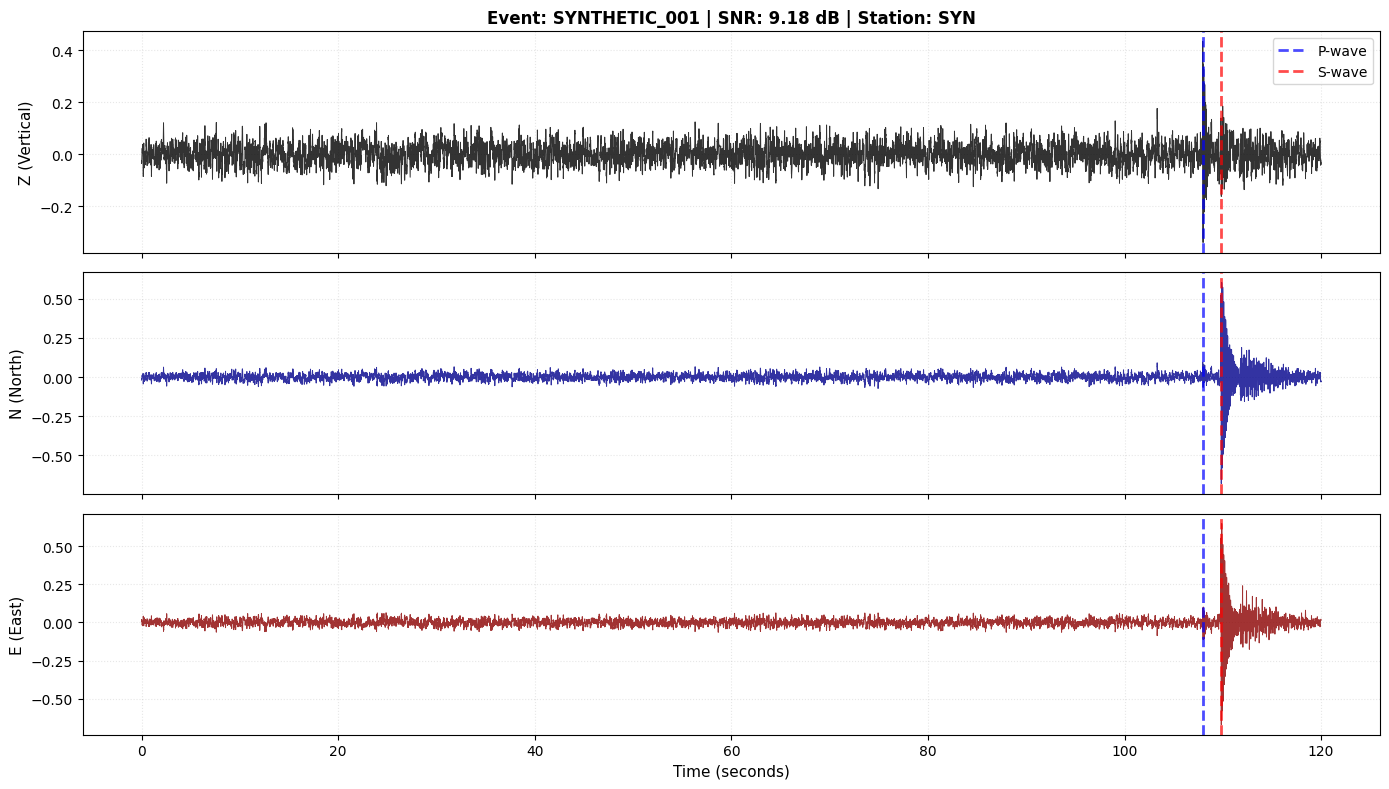


Phase Arrivals:
  P-wave: sample 10795 (107.95 s)
  S-wave: sample 10977 (109.77 s)
  S-P time: 1.82 s


In [7]:
# Extract phase arrival information
p_sample = metadata['trace_p_arrival_sample']
s_sample = metadata['trace_s_arrival_sample']
sampling_rate = metadata['trace_sampling_rate_hz']
snr_db = metadata['trace_snr_db']

# Create time axis
n_samples = waveforms.shape[1]
time_axis = np.arange(n_samples) / sampling_rate

# Plot three components
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
component_names = ['Z (Vertical)', 'N (North)', 'E (East)']
colors = ['black', 'darkblue', 'darkred']

for i, (ax, name, color) in enumerate(zip(axes, component_names, colors)):
    # Plot waveform
    ax.plot(time_axis, waveforms[i], color=color, linewidth=0.7, alpha=0.8)
    
    # Mark phase arrivals
    if not np.isnan(p_sample):
        p_time = p_sample / sampling_rate
        ax.axvline(p_time, color='blue', linestyle='--', linewidth=2, label='P-wave', alpha=0.7)
    
    if not np.isnan(s_sample):
        s_time = s_sample / sampling_rate
        ax.axvline(s_time, color='red', linestyle='--', linewidth=2, label='S-wave', alpha=0.7)
    
    # Formatting
    ax.set_ylabel(name, fontsize=11)
    ax.grid(True, alpha=0.3, linestyle=':')
    
    if i == 0:
        ax.set_title(f"Event: {metadata['source_id']} | SNR: {snr_db:.2f} dB | Station: {metadata['station_code']}", 
                    fontsize=12, fontweight='bold')
        ax.legend(loc='upper right', fontsize=10)

axes[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nPhase Arrivals:")
print(f"  P-wave: sample {p_sample:.0f} ({p_sample/sampling_rate:.2f} s)")
print(f"  S-wave: sample {s_sample:.0f} ({s_sample/sampling_rate:.2f} s)")
print(f"  S-P time: {(s_sample - p_sample)/sampling_rate:.2f} s")

## 5. Load Multiple Traces

Demonstrate loading multiple traces at once for batch processing.

In [8]:
# Load first 4 traces
trace_indices = [0, 1, 2, 3]
waveforms_batch = dataset.get_waveforms(trace_indices)

print(f"Batch waveform shape: {waveforms_batch.shape}")
print(f"  Dimensions: (n_traces, n_components, n_samples)")
print(f"  {waveforms_batch.shape[0]} traces × {waveforms_batch.shape[1]} components × {waveforms_batch.shape[2]} samples")

Batch waveform shape: (4, 3, 12000)
  Dimensions: (n_traces, n_components, n_samples)
  4 traces × 3 components × 12000 samples


## 6. Plot Overview of Multiple Traces

Visualize multiple traces to see the variety in the dataset.

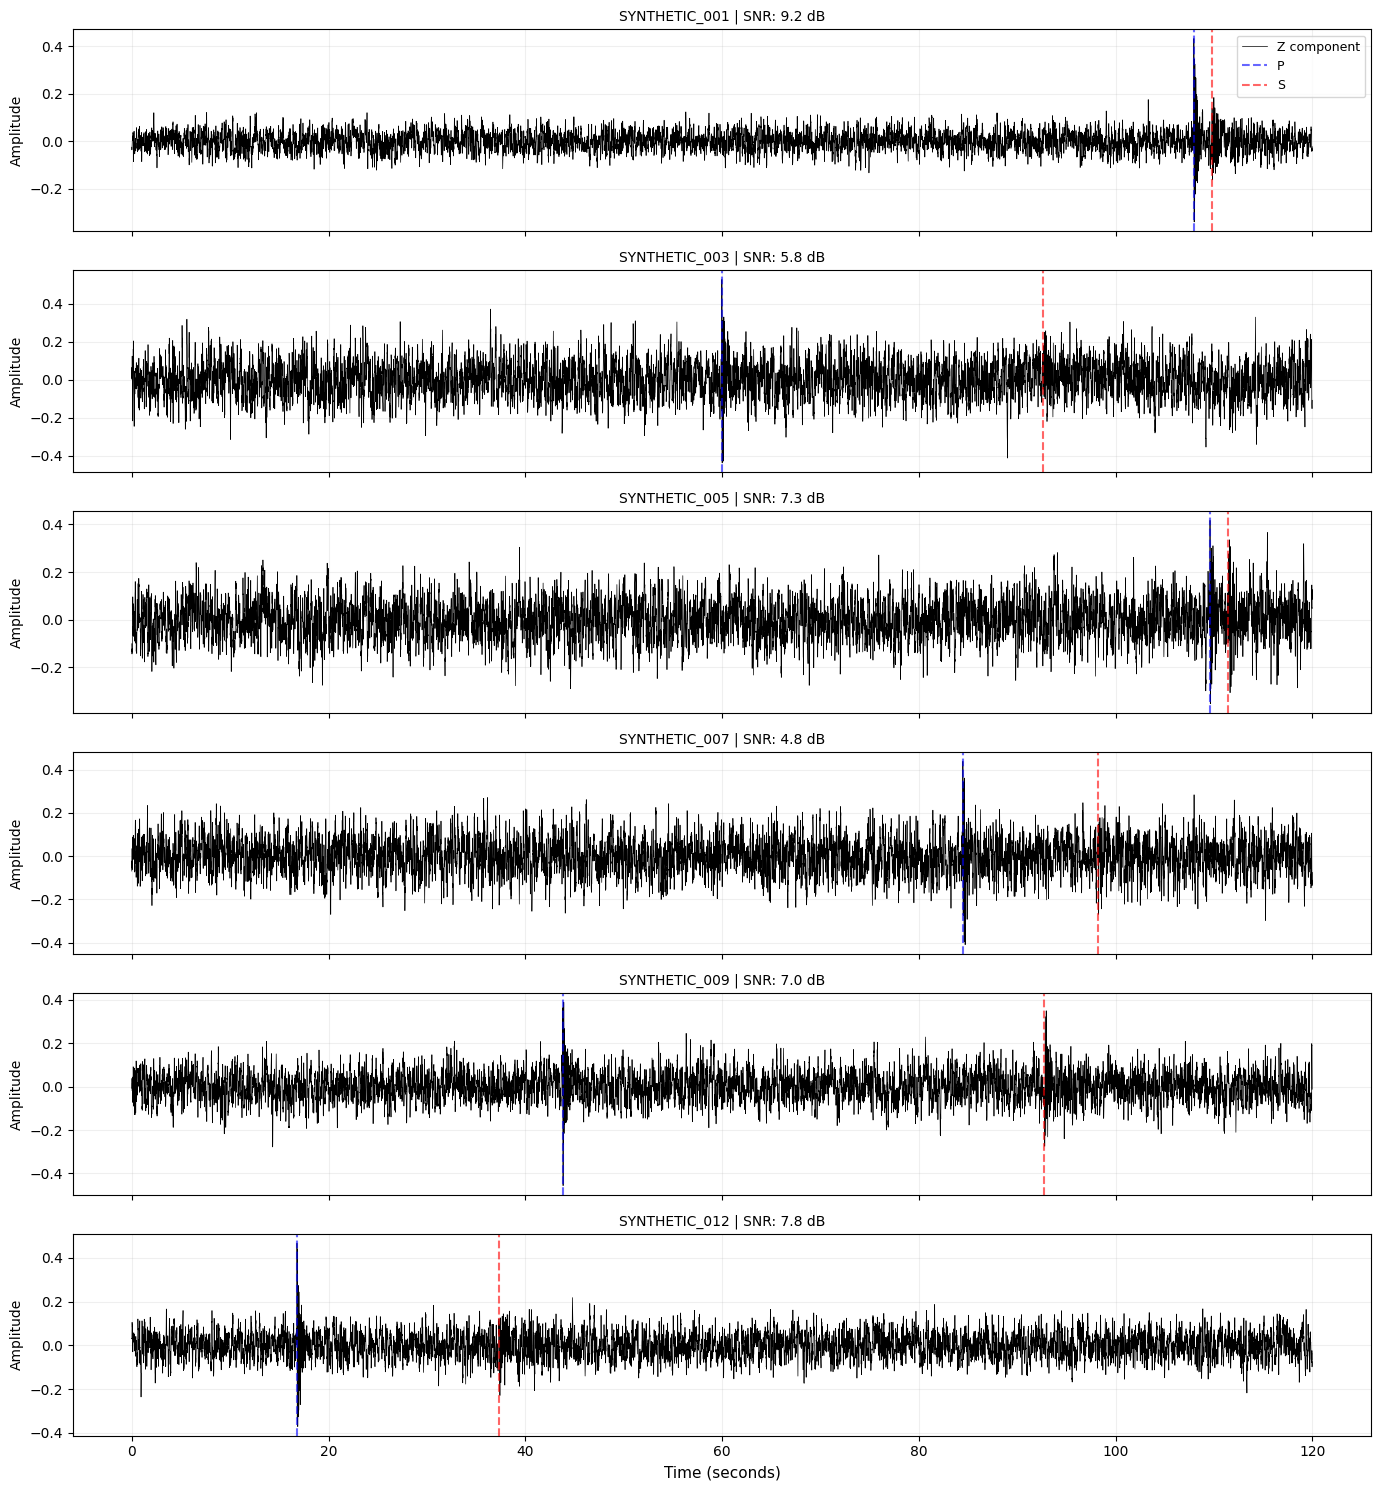

In [13]:
# Select 6 traces to display
n_display = min(6, len(dataset))
indices = np.linspace(0, len(dataset)-1, n_display, dtype=int)

fig, axes = plt.subplots(n_display, 1, figsize=(14, 2.5*n_display), sharex=True)
if n_display == 1:
    axes = [axes]

for idx, ax in zip(indices, axes):
    waveform = dataset.get_waveforms(idx)
    meta = dataset.metadata.iloc[idx]
    
    # Plot Z component only for overview
    time = np.arange(waveform.shape[1]) / meta['trace_sampling_rate_hz']
    ax.plot(time, waveform[0], 'k-', linewidth=0.5, label='Z component')
    
    # Mark picks
    if not np.isnan(meta['trace_p_arrival_sample']):
        ax.axvline(meta['trace_p_arrival_sample'] / meta['trace_sampling_rate_hz'], 
                  color='blue', linestyle='--', alpha=0.6, label='P')
    if not np.isnan(meta['trace_s_arrival_sample']):
        ax.axvline(meta['trace_s_arrival_sample'] / meta['trace_sampling_rate_hz'], 
                  color='red', linestyle='--', alpha=0.6, label='S')
    
    ax.set_ylabel('Amplitude', fontsize=10)
    ax.set_title(f"{meta['source_id']} | SNR: {meta['trace_snr_db']:.1f} dB", fontsize=10)
    ax.grid(True, alpha=0.2)
    if idx == indices[0]:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.tight_layout()
plt.show()


## 7. Filter Dataset by SNR

Demonstrate filtering to select only high-quality traces.

In [10]:
# Create a filter mask for high SNR traces (> 6 dB)
high_snr_mask = dataset.metadata['trace_snr_db'] > 6.0

print(f"Original dataset: {len(dataset)} traces")
print(f"High SNR traces (>6 dB): {high_snr_mask.sum()} traces")

# Create filtered dataset (returns a copy)
high_snr_dataset = dataset.filter(high_snr_mask, inplace=False)

print(f"\nFiltered dataset: {len(high_snr_dataset)} traces")
print(f"SNR range in filtered data: {high_snr_dataset.metadata['trace_snr_db'].min():.2f} - {high_snr_dataset.metadata['trace_snr_db'].max():.2f} dB")

Original dataset: 12 traces
High SNR traces (>6 dB): 6 traces

Filtered dataset: 6 traces
SNR range in filtered data: 7.02 - 9.78 dB


## 8. Direct Access to HDF5 and CSV

You can also directly read the files without using SeisBench, though using SeisBench is recommended.

In [11]:
import h5py

# Read CSV directly with pandas
df = pd.read_csv('../data/metadata.csv')
print("CSV Metadata:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {len(df.columns)}")
print(f"\nFirst row:")
print(df.iloc[0])

CSV Metadata:
  Shape: (12, 22)
  Columns: 22

First row:
station_network_code                        XX
station_code                               SYN
station_location_code                      NaN
trace_channel                               HH
trace_sampling_rate_hz                   100.0
trace_npts                               12000
trace_start_time           1970-01-01T00:00:00
trace_p_arrival_sample                   10795
trace_p_status                          manual
trace_p_weight                             1.0
trace_s_arrival_sample                   10977
trace_s_status                          manual
trace_s_weight                             1.0
source_id                        SYNTHETIC_001
source_origin_time         1970-01-01T00:00:00
source_type                         earthquake
source_magnitude                           2.0
source_magnitude_type                       ML
source_magnitude_author              synthetic
trace_snr_db                          9.182615
sp

In [12]:
# Read HDF5 directly
with h5py.File('../data/waveforms.hdf5', 'r') as f:
    print("HDF5 Structure:")
    print(f"  Keys: {list(f.keys())}")
    
    # Check data_format
    if 'data_format' in f:
        print(f"\n  Data format attributes:")
        for key, value in f['data_format'].attrs.items():
            print(f"    {key}: {value}")
    
    # Access trace data (stored in bucket0)
    if 'bucket0' in f:
        bucket = f['bucket0']
        print(f"\n  Bucket0 shape: {bucket.shape}")
        print(f"  Bucket0 dtype: {bucket.dtype}")
        
        # Read first trace
        first_trace = bucket[0, :, :]
        print(f"\n  First trace shape: {first_trace.shape}")
        print(f"  Components × Samples: {first_trace.shape[0]} × {first_trace.shape[1]}")

HDF5 Structure:
  Keys: ['data', 'data_format']

  Data format attributes:


## 9. Summary

This notebook demonstrated:
- ✅ Loading a SeisBench dataset from disk
- ✅ Inspecting metadata with pandas
- ✅ Accessing waveform data
- ✅ Visualizing 3-component seismograms with phase picks
- ✅ Batch loading multiple traces
- ✅ Filtering datasets by criteria
- ✅ Direct access to CSV and HDF5 files

The synthetic dataset is now ready for use with SeisBench models like PhaseNet and EQTransformer!